In [1]:
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn  import preprocessing
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

## Creacion de la conexion a la bd para eller la tabla "player attributes"

In [464]:
cnx = sqlite3.connect('database.sqlite')

In [465]:
df= pd.read_sql_query("SELECT * FROM Player_Attributes", cnx)

In [466]:
df.head()

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [467]:
df.shape

(183978, 42)

In [468]:
df.columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='object')

### De todas las columnas, determinaremos cuales se  usaran con features para alimentar al modelo

In [645]:
"""
features= ['potential', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes']

       
Se intentó eliminar algunas variables para mejorar la precisión del modelo, pero al hacerlo, el resultado empeoró (bajó de aproximadamente 0.8412690897596591 a 0.84027571791874067). 
Esto indica que las variables numéricas utilizadas sí aportan información importante para la predicción.
También se intentó eliminar features que parecían similares o redundantes, como shot_power, acceleration, dribbling, sliding_tackle y long_passing, pero al quitarlas el desempeño del modelo también disminuyó.
Por esta razón, se decidió mantener todas esas características.
En conclusión, mantener las variables numéricas fue la mejor opción para obtener una mejor precisión.
"""
# Eliminar Features relacionados con otros similares 'shot_power', 'acceleration' , 'dribbling' ,'sliding_tackle' 
features = [
 'potential', 'crossing', 'finishing', 'heading_accuracy',
 'short_passing', 'volleys', 'curve',
 'free_kick_accuracy', 'long_passing', 'ball_control',
  'sprint_speed', 'agility', 'reactions',
 'balance','jumping', 'stamina', 'strength',
 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision','standing_tackle',
  'penalties', 'marking', 'gk_diving', 'gk_handling',
 'gk_kicking', 'gk_positioning', 'gk_reflexes'
]

### Seleccionamos el target

In [646]:
target = ['overall_rating']

## Limpiar los datos eliminados filas con valores nan

In [647]:
df= df.dropna()

### Separamos las features en X , el target en Y

In [648]:
x = df[features]
y = df[target]

### Mostrar el contenido de una fila de conjunto x

In [649]:
x.iloc[5]

potential             76.0
crossing              80.0
finishing             53.0
heading_accuracy      58.0
short_passing         71.0
volleys               40.0
curve                 70.0
free_kick_accuracy    69.0
long_passing          68.0
ball_control          71.0
sprint_speed          78.0
agility               78.0
reactions             67.0
balance               90.0
jumping               85.0
stamina               79.0
strength              56.0
long_shots            62.0
aggression            68.0
interceptions         67.0
positioning           60.0
vision                66.0
standing_tackle       75.0
penalties             59.0
marking               76.0
gk_diving             14.0
gk_handling            7.0
gk_kicking             9.0
gk_positioning         9.0
gk_reflexes           12.0
Name: 5, dtype: float64

In [650]:
x.head()

,potential,crossing,finishing,heading_accuracy,short_passing,volleys,curve,free_kick_accuracy,long_passing,ball_control,...,positioning,vision,standing_tackle,penalties,marking,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,71.0,49.0,44.0,71.0,61.0,44.0,45.0,39.0,64.0,49.0,...,45.0,54.0,69.0,48.0,65.0,6.0,11.0,10.0,8.0,8.0
1,71.0,49.0,44.0,71.0,61.0,44.0,45.0,39.0,64.0,49.0,...,45.0,54.0,69.0,48.0,65.0,6.0,11.0,10.0,8.0,8.0
2,66.0,49.0,44.0,71.0,61.0,44.0,45.0,39.0,64.0,49.0,...,45.0,54.0,66.0,48.0,65.0,6.0,11.0,10.0,8.0,8.0
3,65.0,48.0,43.0,70.0,60.0,43.0,44.0,38.0,63.0,48.0,...,44.0,53.0,63.0,47.0,62.0,5.0,10.0,9.0,7.0,7.0
4,65.0,48.0,43.0,70.0,60.0,43.0,44.0,38.0,63.0,48.0,...,44.0,53.0,63.0,47.0,62.0,5.0,10.0,9.0,7.0,7.0


In [651]:
y. head()

,overall_rating
0,67.0
1,67.0
2,62.0
3,61.0
4,61.0


### Muestreo de los valores de los features "reactions" para cada jugador

In [652]:
x['reactions']

0         47.0
1         47.0
2         47.0
3         46.0
4         46.0
          ... 
183973    86.0
183974    74.0
183975    74.0
183976    69.0
183977    66.0
Name: reactions, Length: 180354, dtype: float64

### Imprimir la relacion existente entre el feature "reactions" y el targer "overall_rating"

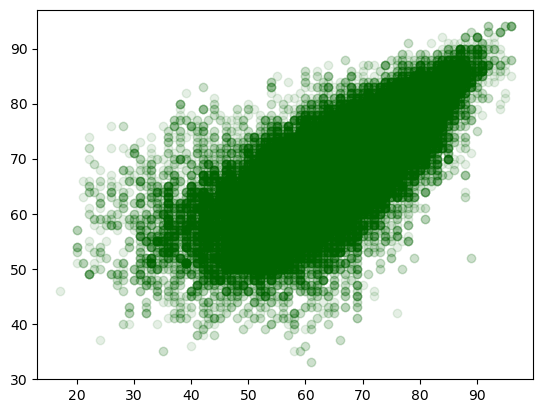

In [653]:
plt.scatter(x['reactions'], y , color= 'darkgreen', label ='Datos', alpha=.1)

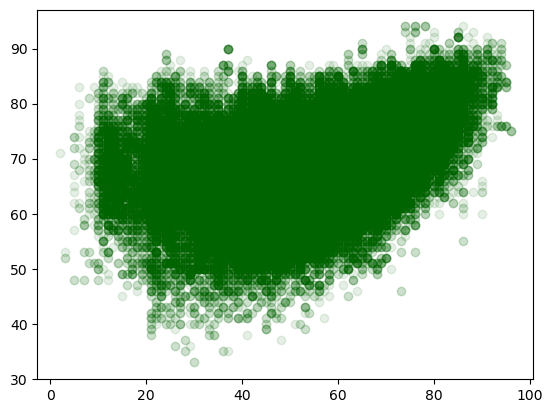

In [654]:
plt.scatter(x['penalties'], y , color= 'darkgreen', label ='Datos', alpha=.1)

### Separacion de los datos en Training y Test Datasets


In [655]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.33, random_state=324)

### Utiliza un escalado estandar
para que los dattos de cada feature se acople a un rango y se eviten los sesgos de un feature con valores muy altos que puedan influir de mas en el target

In [656]:
scale = preprocessing.StandardScaler()

In [657]:
scale.fit(x_train)

,copy,True
,with_mean,True
,with_std,True


In [658]:
x_train = scale.transform(x_train)

In [659]:
# imprimit los nuevos valores minimo y maximo de los features de entrenamiento
x_train.min()

np.float64(-5.377337896778157)

In [660]:
x_train.max()

np.float64(4.9683467491419835)

### Creamos una instancia del modelo de Regresión lineal de Scikit learn

In [661]:
regresor = LinearRegression()

## Ajustando el modelo a los datos de entrenamiento

In [662]:
regresor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Realizar una prediccion usando conjutos de datos de prueba (test set)

In [663]:
# escalar los valores de prueba para coicidan con los de entrenamiento
x_test = scale.transform (x_test)

In [664]:
# hacer una prediccion del valor de salida , pasandole los valores de prueba
y_prediction= regresor.predict(x_test)

In [665]:
# obtener la difencia que hay entre los valores de salida predichos contra los valores de salida real
y_result= y_prediction - y_test
y_result

,overall_rating
35543,0.481992
28735,-2.805852
168029,1.507050
138117,0.911594
123316,1.486643
...,...
51151,-2.163755
155333,-1.233165
118067,-1.671243
62126,2.300697


### Calcular la raiz cuadrada del error cuadratico medio

In [666]:
RMSE = sqrt(mean_squared_error(y_true=y_test, y_pred= y_prediction))
print(RMSE)

2.814067447823896


### Mostrar la precision que obtuvo el modelo al predecir con los valores de prueba

In [667]:
regresor.score(x_test,y_test)

0.8402757179187406

### Mostrar cual es el valor de cada W que se aplico a cada feature (w * X) para que al sumar todos los productos nos de el puntuaje de cada jugador

In [644]:
regresor.coef_

array([[ 2.48554391,  0.31803554,  0.26968723,  1.18331237,  0.70713135,
         0.08152396,  0.16739294,  0.25141821,  0.07586458,  1.96798204,
         0.1675283 , -0.10137137,  1.92984076,  0.10371057,  0.15827192,
        -0.08225929,  0.77359814, -0.13596372,  0.33768721,  0.16253072,
        -0.20995997,  0.26046572,  0.31450841,  2.75364595,  0.52331876,
        -0.71880685,  0.91914725,  0.44166035]])